## Oppgave 4
### a)

Kopierer litt av koden din Erik, siden koden i 4b) bygger på 2.


In [27]:
import numpy as np
from matplotlib import pyplot as plt
import random
#programmet er strukturert slik at konstanter defineres først og brukes deretter globalt av funksjonene

"""Velger å ta med vegger på 0 og 80, slik at partiklene ikke kan hoppe fra start til slutt
Rett på meg hvis det blir feil."""

#konstanter
beta_k = 1000
# Spatial periods. Hvor mange steg før man er tilbake på en sagtanntopp.
Nx = 20
# Lengden på x-aksen. Har 4 sagtenner.    
L = 4*Nx
#Bruk periodisk boundary condition
Tp = 40 #Periode i tid. Så lenge gjelder potensial 1, før det bytter til potensial 2.
timeSteps = 10*Tp  # Skal være 10 i oppgaven

alfa = 0.2  # Faller mot høyre                   
# Total tid er 5 sykluser. Det betyr at Tp skal kjøre 10 ganger, siden to Tp er en syklus.
# Plot posisjon ved hvert tidssteg. Her bør jeg bruke en animasjon!!
# Passende x-akse?
x_axis = np.arange(0, 80, 81)
particleCount = 8     # Antall partikler.
particleSize = 5

# Bruker heller metoden fra tidligere, der partikkel i har poisjon x[i]
initParticlePos = np.linspace(0, 60, particleCount)   # Bruk L i midten!
listPosition = []

for n in range(len(initParticlePos)):
    listPosition.append(int(initParticlePos[n]))

print(initParticlePos)
print(listPosition)      # Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.

print(type(listPosition[0]))


[ 0.          8.57142857 17.14285714 25.71428571 34.28571429 42.85714286
 51.42857143 60.        ]
[0, 8, 17, 25, 34, 42, 51, 60]
<class 'int'>


In [28]:
def occupied(particlePos):
    occupiedMatrix = np.zeros((particleCount, 3))    
    """occupiedMatrix[i][0] = partikkels senter, occupiedMatrix[i][1] = venstre, occupiedMatrix[i][2] = høyre
    Kan endres på dersom noe annet gir mer mening."""
    for pos in range(len(particlePos)):
        occupiedMatrix[pos][0] = particlePos[pos]
        occupiedMatrix[pos][1] = (particlePos[pos] - (particleSize) // 2) % L
        occupiedMatrix[pos][2] = (particlePos[pos] + (particleSize) // 2) % L
    return occupiedMatrix

print(occupied(listPosition))

[[ 0. 78.  2.]
 [ 8.  6. 10.]
 [17. 15. 19.]
 [25. 23. 27.]
 [34. 32. 36.]
 [42. 40. 44.]
 [51. 49. 53.]
 [60. 58. 62.]]


In [39]:
#Potensialer
def V1(x):                #uten k fordi den inngår i p_pos
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return -(periode-Nx)/((1-alfa)*Nx)

def V2(x):                          #også uten k for samme grunn
    return 0

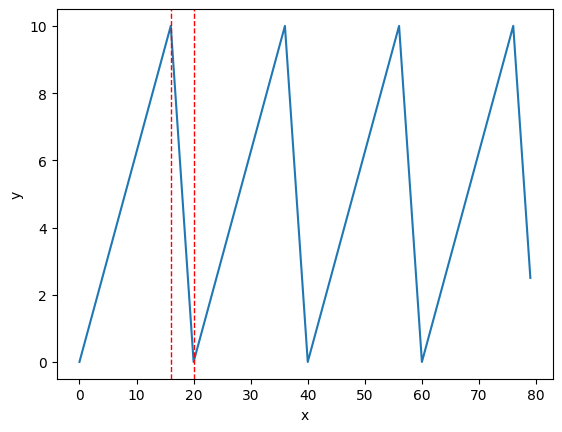

In [37]:
# Prøver å forstå alt sammen. Tegner potensialet.
# Må modifisere litt. Kan ikke sammenligne et helt array med periode, siden hver verdi for forskjellig bool-verdi.
alfa = 0.8
def V1_test(x):
    potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
    for i in range(len(x)):
        Hvor_i_periode = x[i] % Nx
        if Hvor_i_periode <= alfa*Nx:
            potensialer[i] = 10*Hvor_i_periode/(alfa*Nx)
        else:
            potensialer[i] = -10*(Hvor_i_periode-Nx)/((1-alfa)*Nx) 
    return potensialer
    
x_axis = np.arange(0, L, 1)
y_potential = V1_test(x_axis)
plt.plot(x_axis, V1_test(x_axis))
plt.xlabel("x")
plt.ylabel("y")
plt.axvline(x=16, color='red', linestyle='--', linewidth=1, label='x=2')
plt.axvline(x=20, color='red', linestyle='--', linewidth=1, label='x=20')
plt.show()

In [43]:
#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V):

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1)%L)-V((x+1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x+1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V):

    arg1 = np.clip(-beta_k*(V((x-1)%L)-V(x%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1)%L)-V(x%L)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


def p_neg(x, V):

    arg1 = np.clip(-beta_k*(V((x+1)%L)-V((x-1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x-1)%L)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner

def lookUpTabell_V1():
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1    # Her bruker vi potensial V1!
    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V)
        tabell_V1_p_neg[x] = p_neg(x, V)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2():
    p_pos_val = p_pos(1, V2)
    p_neg_val = p_neg(1, V2)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#lager look up tabell som gjør at ting går mye raskere
tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1()
tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2()

a= 20
b= 1
print(f'Venstre: {tabell_V1_p_neg[a]}, høyre: {tabell_V1_p_pos[a]}')
print(0.8*20)

Venstre: 2.6691902155411246e-109, høyre: 7.187781739060989e-28
16.0


In [44]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.

def enSimulasjon_4a():
    positionsOverTime = []
    particlePos = listPosition.copy()
    rightIndex = 2
    leftIndex = 1
    queue = list(range(particleCount))
    
    occupiedMatrix = occupied(particlePos)
    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        random.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:
            tilfeldigtall = np.random.rand()
            x = particlePos[index]                            # Må sjekke kollisjon for hver partikkel
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if (x-1) == occupiedMatrix[index-1][rightIndex]:
                    continue
                x -= 1
            elif tilfeldigtall >= (1 - tabell_p_pos[x% L]):
                if (x+1) == occupiedMatrix[(index + 1) % particleCount][leftIndex]:
                    continue
                x += 1
            particlePos[index] = x % (L)                      # Hopper tilbake til start.
            occupiedMatrix = occupied(particlePos)
    
            # print(particlePos)
        positionsOverTime.append(particlePos.copy())


    return positionsOverTime

positions_Over_Time = enSimulasjon_4a()

In [46]:
import plotly.graph_objects as go

# Example: list of position snapshots over time
# Each inner list = positions of balls at that timestep
positions_over_time = positions_Over_Time
# print(positions_over_time)

num_balls = len(positions_over_time[0])

# Create frames
frames = []
for t, positions in enumerate(positions_over_time):
    whichPotential = ( t // Tp) % 2
    if whichPotential == 0:
        potensial = "Sagtann"
        frames.append(
            go.Frame(
                data=[
                    go.Scatter(
                        x=positions,
                        y=[y_potential[coord] for coord in positions],
                        mode="markers",
                        marker=dict(size=12),
                        name = "Random walk paritcles"
                    )
                ],
                layout= go.Layout(
                    annotations=[
                        dict(
                            text=f"Frame: {t}, potensial = {potensial}",
                            x=0.95,
                            y=0.95,
                            xref = "paper",
                            yref = "paper",
                            showarrow = False,
                            font=dict(size=20)
                        )
                    ]
                ),
                name=str(t)
            )
        )
    
    else:
        potensial = "flatt"
        frames.append(
            go.Frame(
                data=[
                    go.Scatter(
                        x=positions,
                        y=[0]*num_balls,
                        mode="markers",
                        marker=dict(size=12)
                    )
                ],
                layout= go.Layout(
                    annotations=[
                        dict(
                            text=f"Frame: {t}, potensial = {potensial}",
                            x=0.95,
                            y=0.95,
                            xref = "paper",
                            yref = "paper",
                            showarrow = False,
                            font=dict(size=20)
                        )
                    ]
                ), 
                name=str(t)
            )
    )

# Initial figure
fig = go.Figure(
    data=[
        go.Scatter(
            x=positions_over_time[0],
            y=[0]* num_balls,
            mode="markers",
            marker=dict(size=12)
        )
    ],
    frames=frames
)

# Add slider (frame counter)
fig.update_layout(
    sliders=[{
        "currentvalue": {"prefix": "Frame: "},
        "steps": [
            {
                "args": [[f.name], {"frame": {"duration": 50, "redraw": True},
                                    "mode": "immediate"}],
                "label": f.name,
                "method": "animate"
            }
            for f in frames
        ]
    }]
)

# Add play button
fig.update_layout(
    xaxis=dict(range=[0, L], title="Position"),
    yaxis=dict(range=[-10, 20]),
    updatemenus=[
        dict(
            type="buttons",
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[None, {"frame": {"duration": 200, "redraw": True},
                                 "fromcurrent": True}]
                )
            ]
        )
    ]
)

# Potential curve
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y= y_potential if whichPotential == 0 else 0,
        mode="lines",
        name="Potential"
    )
)

fig.show()